In [1]:
# Autoload modules
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('../../')
from fcc import MiyazawaJerniganInteraction, Peptide, ProteinFoldingProblem, PenaltyParameters, ProteinFoldingResult
from vqe import VQEC
from qiskit.circuit.library import RealAmplitudes
from qiskit.primitives import Sampler, Estimator
from qiskit_algorithms.gradients import ParamShiftEstimatorGradient, LinCombEstimatorGradient
import numpy as np
import matplotlib.pyplot as plt
#import dcd_ansatz, commutator_funcs

In [3]:
def build_pf(main_seq: str, energy_matrix_file: str = "mj_matrix"):
    """Builds the protein folding problem for the given sequence."""

    mj_interaction = MiyazawaJerniganInteraction(energy_matrix_file)
    print(mj_interaction.calculate_energy_matrix(main_seq))

    penalty_back = 50
    penalty_redun = 50
    # penalty_olap = 50

    penalty_terms = PenaltyParameters(penalty_back, penalty_redun)

    peptide = Peptide(main_seq)

    protein_folding_problem = ProteinFoldingProblem(peptide, mj_interaction, penalty_terms)

    return protein_folding_problem

In [4]:
main_seq_4 = "AAAAA" # 6MVZ ("LFLF")
protein_folding_problem = build_pf(main_seq_4)
qubit_op = protein_folding_problem.qubit_op()
print(f"Number of qubits: {qubit_op.num_qubits}")
print(f"Number of terms: {len(qubit_op)}")

[[ 0.   -2.72 -2.72 -2.72 -2.72]
 [ 0.    0.   -2.72 -2.72 -2.72]
 [ 0.    0.    0.   -2.72 -2.72]
 [ 0.    0.    0.    0.   -2.72]
 [ 0.    0.    0.    0.    0.  ]]
Number of qubits: 16
Number of terms: 702


In [5]:
bead_pairs, olap_constr_ops = protein_folding_problem.olap_constr_ops()
print(f"Number of overlap constraints: {len(olap_constr_ops)}")
print(f"Number of qubits: {olap_constr_ops[0].num_qubits}")

Number of overlap constraints: 3
Number of qubits: 16


In [6]:
ansatz = RealAmplitudes(qubit_op.num_qubits, reps=1)
estimator = Estimator()
gradient = LinCombEstimatorGradient(estimator=estimator)
vqec = VQEC(qubit_op=qubit_op, constr_ops=olap_constr_ops, ansatz=ansatz, estimator=estimator, gradient=gradient)
vqec_result = vqec.optimize_primal_dual()
print(vqec_result.optimal_primal_vars)
print(vqec_result.optimal_dual_vars)

Converged after 72 iterations
[ 4.71108277  1.57079633  4.71238898  3.14159265  3.14159265  3.1415691
  2.74368155  1.63601543  4.71238898  3.23084638 -1.15542734  1.56893015
  1.57079633  4.71238898  1.57079633  1.57079633  1.56949012  1.57079641
  4.71238898  4.71238898  3.14159265  6.28316119  1.53435433  4.83280481
  1.57079633  4.71238898  4.29706233  1.56620185  1.57079632  4.72023968
  4.71190294  4.71290686]
[0. 0. 0.]


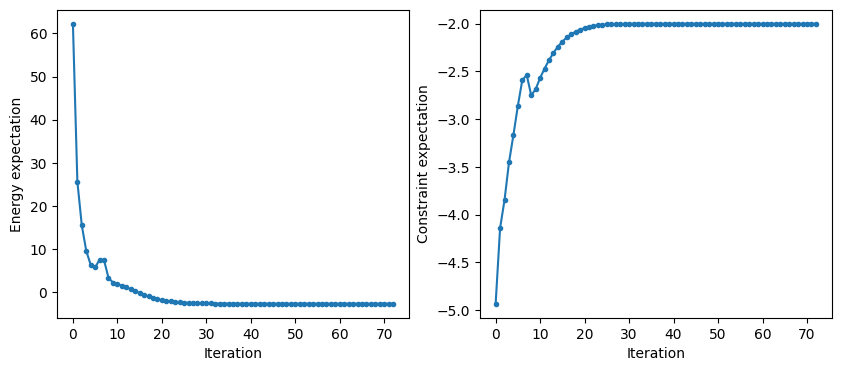

In [7]:
# Plot the results
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(vqec_result.energies, label="Energy", marker=".")
ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("Energy expectation")

ax[1].plot(vqec_result.constraints[:, 0], label="Overlap", marker=".")
ax[1].set_xlabel("Iteration")
ax[1].set_ylabel("Constraint expectation")

plt.show()

In [8]:
full_circ = vqec_result.ansatz.copy()
full_circ.measure_all()
sampler = Sampler(options={"shots": 10000})
sampler_result = sampler.run(circuits=[full_circ], parameter_values=vqec_result.optimal_primal_vars).result()
quasi_dist = sampler_result.quasi_dists[0].binary_probabilities()

# Sort the binary strings by their probabilities
sorted_quasi_dist = dict(sorted(quasi_dist.items(), key=lambda item: item[1], reverse=True))
# Compute the energies of all samples
from qufold.execution_utils.measurements import _evaluate_sparsepauli
bitstring_energies = {}
for i, (sample, prob) in enumerate(sorted_quasi_dist.items()):
    # if i >= 10:
    #     break
    energy = _evaluate_sparsepauli(sample, qubit_op)
    bitstring_energies[sample] = energy
    print(f"Sample {i}: {sample} with probability {prob} and energy {energy}")

Sample 0: 0010001101010101 with probability 0.183 and energy -2.7200000000000024
Sample 1: 0010001101011010 with probability 0.1801 and energy -2.720000000000006
Sample 2: 0010000010010101 with probability 0.1656 and energy -2.720000000000006
Sample 3: 0010000010011010 with probability 0.1614 and energy -2.7199999999999935
Sample 4: 0010001100010101 with probability 0.0905 and energy -2.720000000000005
Sample 5: 0010001100011010 with probability 0.0905 and energy -2.7200000000000006
Sample 6: 0010000011011010 with probability 0.0656 and energy -2.720000000000008
Sample 7: 0010000011010101 with probability 0.0591 and energy -2.719999999999998
Sample 8: 0010000000011010 with probability 0.0011 and energy -2.7200000000000024
Sample 9: 0010000000010101 with probability 0.001 and energy -2.720000000000006
Sample 10: 0010000001011010 with probability 0.0007 and energy -2.720000000000015
Sample 11: 0010000001010101 with probability 0.0006 and energy -2.7200000000000006
Sample 12: 001000111101

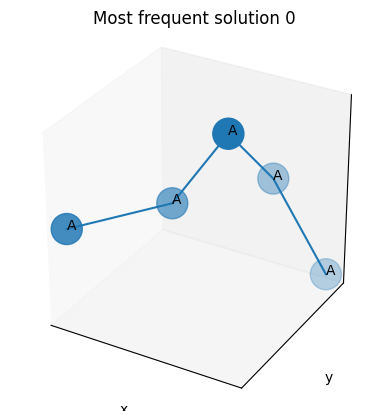

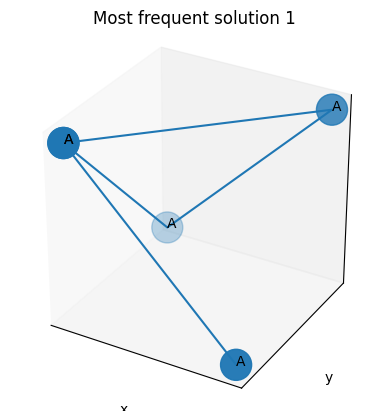

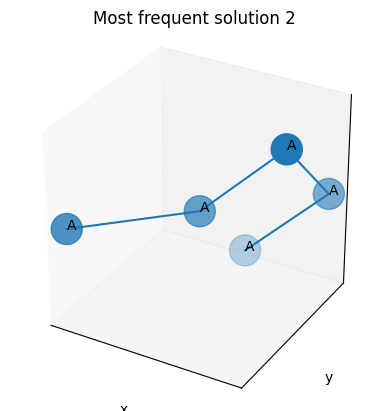

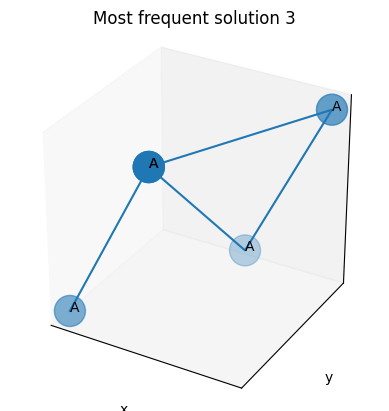

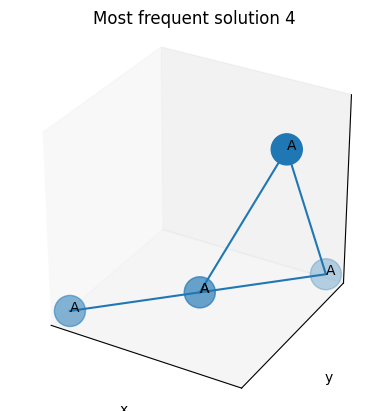

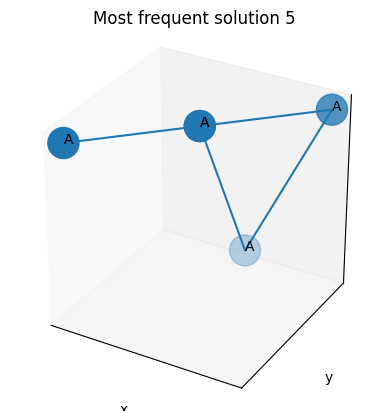

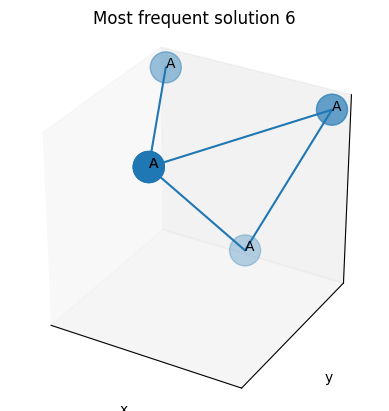

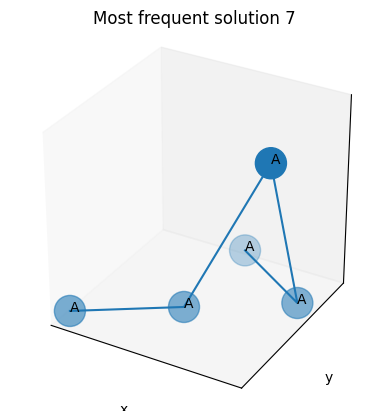

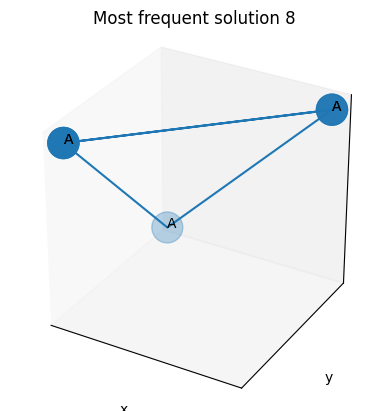

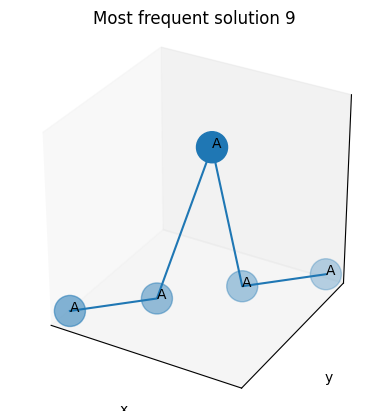

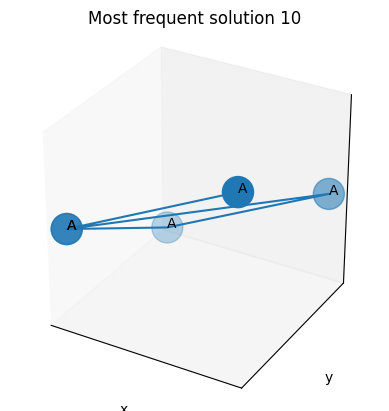

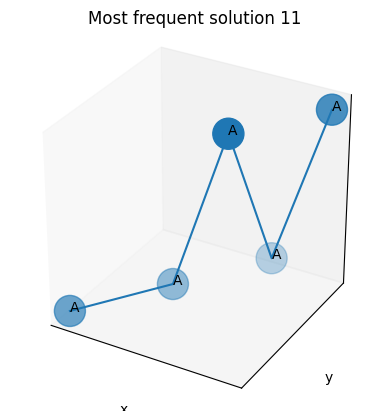

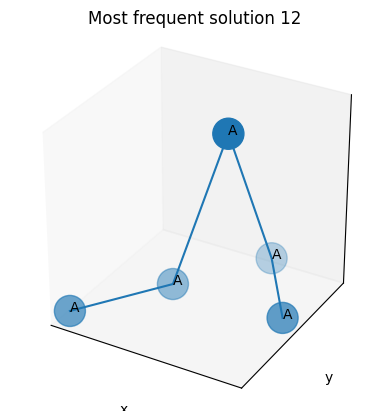

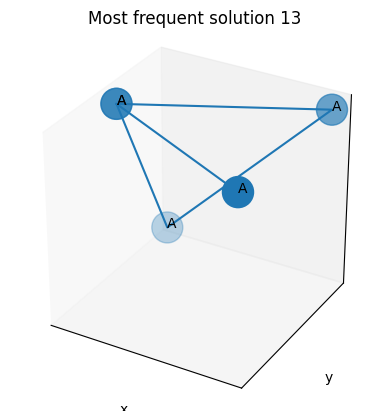

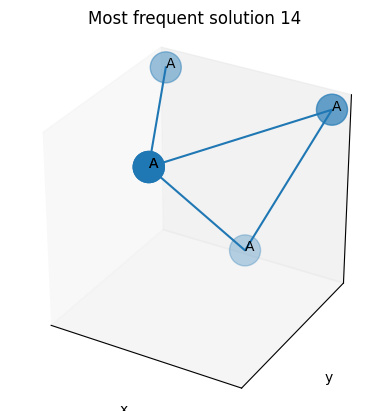

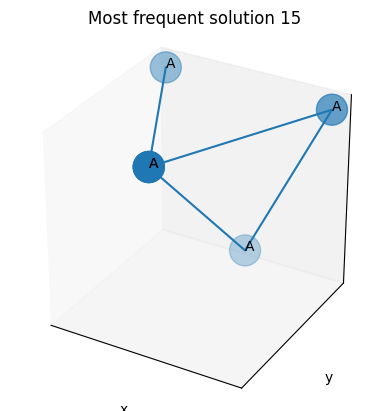

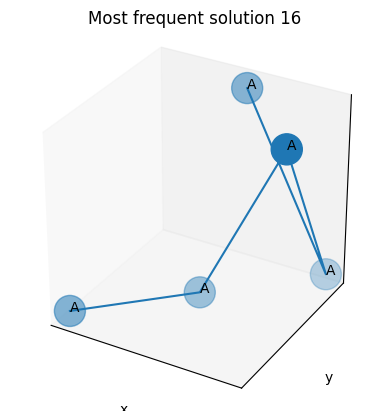

In [9]:
for i, (sample, energy) in enumerate(bitstring_energies.items()):
    pf_result = ProteinFoldingResult(peptide=protein_folding_problem.peptide, unused_qubits=protein_folding_problem.unused_qubits, solution_bitstring=sample)
    fig = pf_result.get_figure(title=f"Most frequent solution {i}")
    plt.show()